## Which solution is the best? 

When dealing with multiple objectives, there is no optimal solution that works best for all the objectives - there are tradeoffs. However, there could be "optimal" solutions from different perspectives. Our AI algorithm identifies an "optimal" solution from four different perspectives:
- Specializers: Solutions that specialise in one specific objective
- Generalizers: Solutions that generalise across multiple objectives. A generalizer is the minimum worst ranking across all the objectives. 
- Resilient: Solutions that are resilient across diverse scenarios
- Sensitive: Solutions that are sensitive to scenarios

## Example Case Study: MoCoDo 2024 Formulation

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload 

In [2]:
USER_PATH = '../../../data/DataExchangeMilan_Project2.2a'
DATA_PATH = 'processed'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)

os.listdir(path)

['mocodo_design_data.csv',
 'scenarios_wrevenues.csv',
 '.DS_Store',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'design_solutions_v0.csv',
 'mocodo_control_data.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

In [3]:
df_design = pd.read_csv(os.path.join(path, 'design_solutions.csv'), index_col=[0, 1])#.loc[(slice(None), 'TESLA'), :]
df_design

Cable Capacity(MW)  Battery Rated Power(MW)  \
Use Case   Location                                                  
Base       COTTONWOOD         2600.000000                36.200000   
           JOHNDAY            2600.000000                47.000000   
           MOSSLAND           2600.000000                36.000000   
           TESLA              5200.000000                52.800000   
           WCASCADE           2600.000000                30.000000   
No ESS     COTTONWOOD         1991.001203                 0.000000   
           JOHNDAY            2585.000202                 0.000000   
           MOSSLAND           1980.000054                 0.000000   
           TESLA              2904.000009                 0.000000   
           WCASCADE           1650.001811                 0.000000   
No Reserve COTTONWOOD         1991.000362                 0.015596   
           JOHNDAY            2585.000076                 0.002795   
           MOSSLAND           1980.000015                 0.002201   
           TESLA              2904.000016                 0.001348   
           WCASCADE           1650.000131                 0.008876   
CCD18_3    COTTONWOOD         1991.029248                54.300003   
           JOHNDAY            2585.009992                70.499999   
           MOSSLAND           1980.003137                53.999993   
           TESLA              2904.001129                79.200000   
           WCASCADE           1650.006081                45.000000   
CCD18_5    COTTONWOOD         1991.037056                54.299998   
           JOHNDAY            2585.013157                70.499883   
           MOSSLAND           1980.001935                53.996802   
           TESLA              2904.001711                79.199999   
           WCASCADE           1650.007926                44.999968   
CCD18_8    COTTONWOOD         1991.058035                52.534622   
           JOHNDAY            2584.999080                61.202332   
           MOSSLAND           1979.998289                39.936632   
           TESLA              2904.008432                65.888878   
           WCASCADE           1650.023596                40.079054   
CCD22_3    COTTONWOOD         1991.023489                90.499991   
           JOHNDAY            2585.003001               117.500000   
           MOSSLAND           1980.046451                89.999778   
           TESLA              2904.004155               131.999982   
           WCASCADE           1650.006875                75.000000   
CCD22_5    COTTONWOOD         1991.036236                90.498599   
           JOHNDAY            2585.004206               117.499458   
           MOSSLAND           1980.019071                89.999729   
           TESLA              2904.003173               131.999984   
           WCASCADE           1650.005357                75.000000   
CCD22_8    COTTONWOOD         1991.064793                54.300083   
           JOHNDAY            2585.007466                70.500001   
           MOSSLAND           1980.027603                54.000123   
           TESLA              2904.004470                79.200095   
           WCASCADE           1650.015151                45.000245   

                       Cable Material Cost($M)  Battery Cost($M)  \
Use Case   Location                                                
Base       COTTONWOOD               261.818246         32.184081   
           JOHNDAY                  358.915986         41.785961   
           MOSSLAND                 533.607121         32.006268   
           TESLA                    974.931412         46.942526   
           WCASCADE                 440.190421         26.671890   
No ESS     COTTONWOOD               200.492478          0.000000   
           JOHNDAY                  356.845345          0.000000   
           MOSSLAND                 406.362357          0.000000   
           TESLA                    544.461698      

In [4]:
sys.path.append("../")
import tradeoff_lattice as tl; reload(tl)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)



/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Specializers/Generalizers
- Base case across all the locations is helping in maximing the real-time revenue and reserve WF revenue.
- No ESS and No Reserve will cause minimum cable and battery installation and maintainence cost.
- CCD22 is most effective for maximing day-ahead revenue.
- CCD18_3 generalises well across all the locations. 

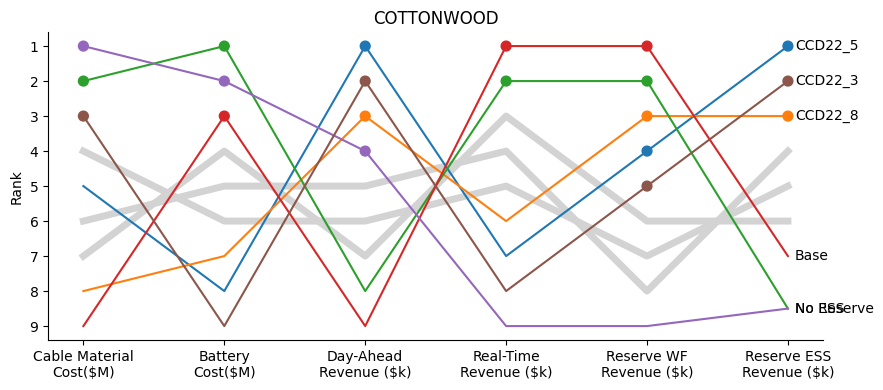

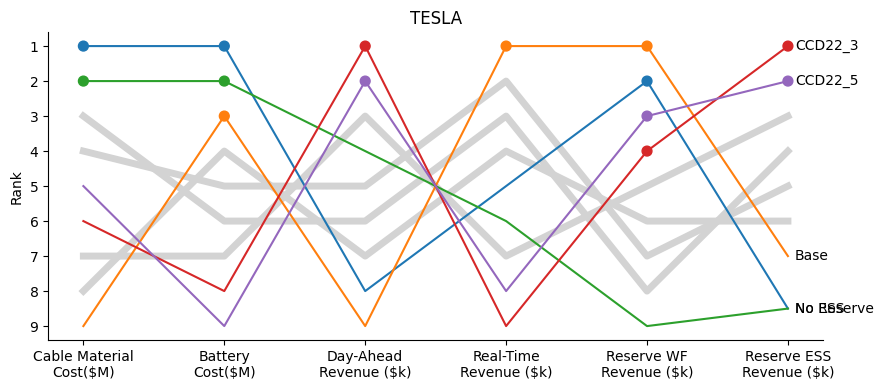

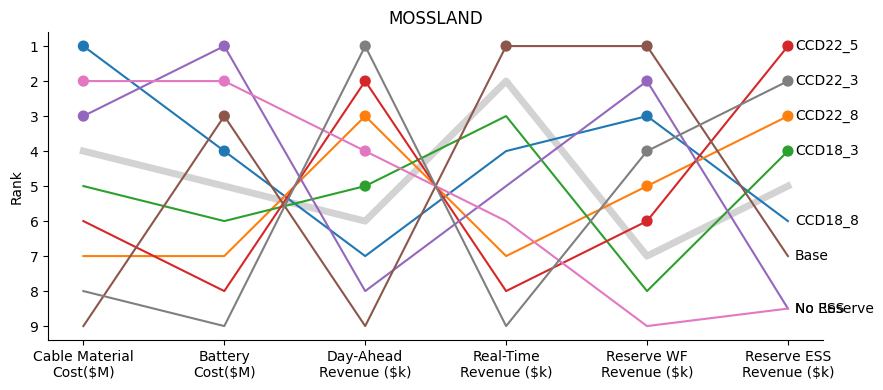

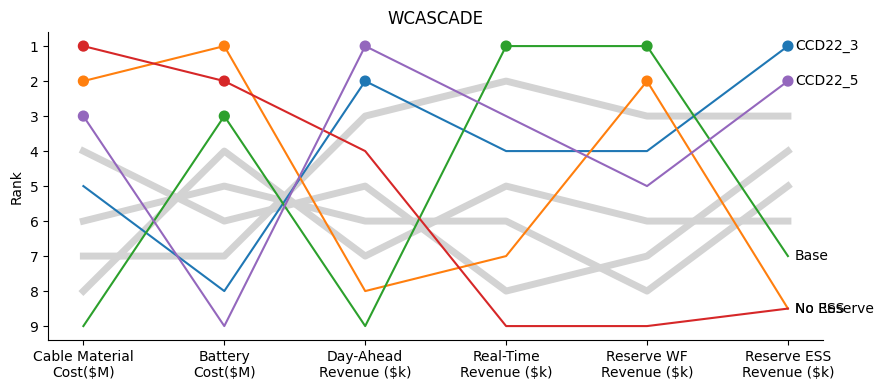

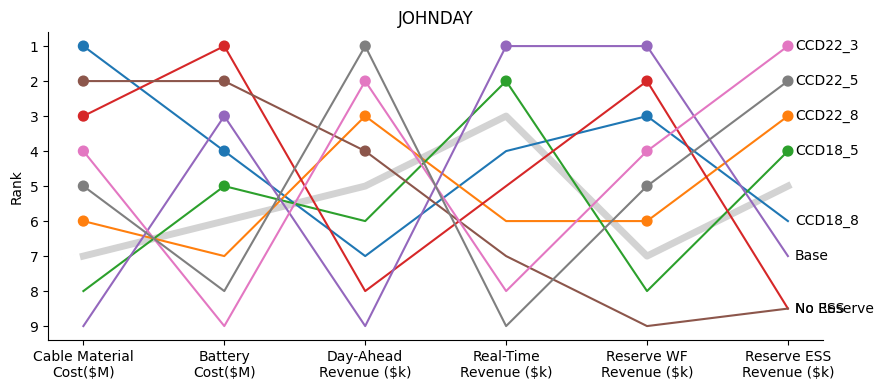

In [5]:
for loc in ["COTTONWOOD", "TESLA", "MOSSLAND", "WCASCADE", "JOHNDAY"]:
    self = tl.DirectTradeoffLattice(
        df_design.loc[(slice(None), loc), :].droplevel(1), ovars, dvars,
        ascending=ascending,
        # max_specializers=1,
        min_specializers=1,
        # n_generalizers=2,
    )
    
    plt.figure(figsize=(10, 4))
    self.plot_ovars_parallel_coords(
        x_label_format=ovar_format,
        use_rank=True,
        include_all_generalizers=True,
        reorder=False,
        highlight_generalizers=False
        # facets = [
        #     i[1]
        #     for i in self.rank.index
        # ]
    )
    plt.title(loc)
    
    plt.subplots_adjust(hspace=1)

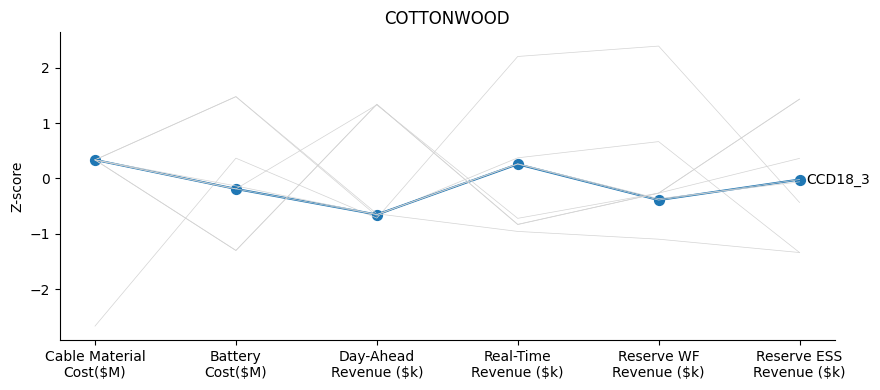

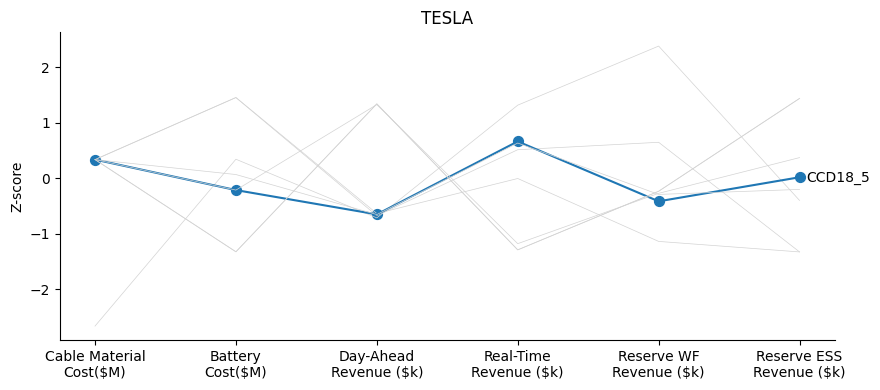

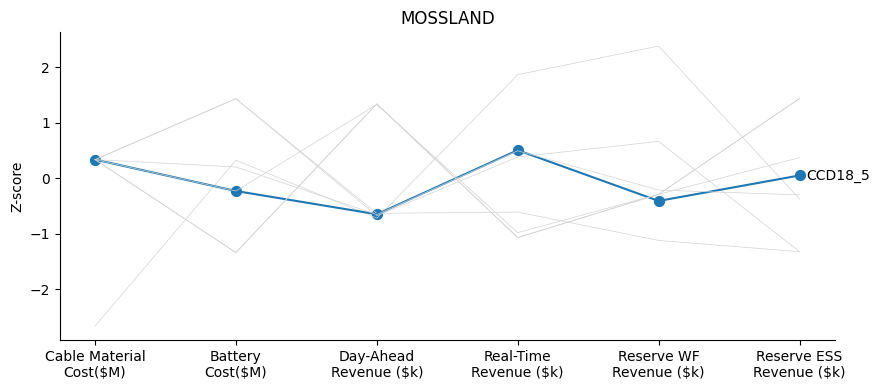

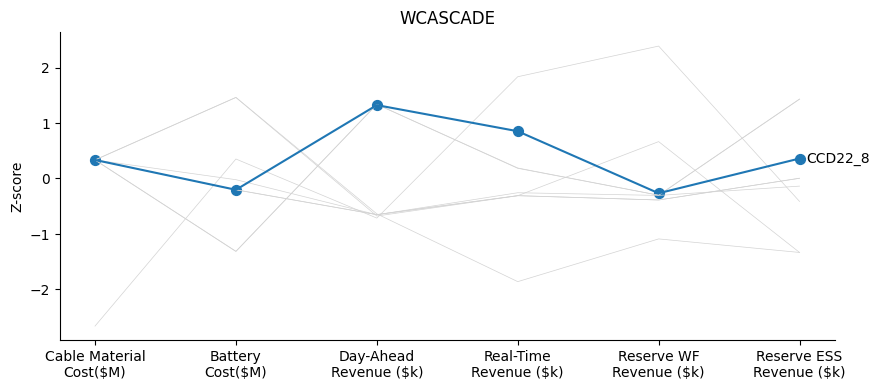

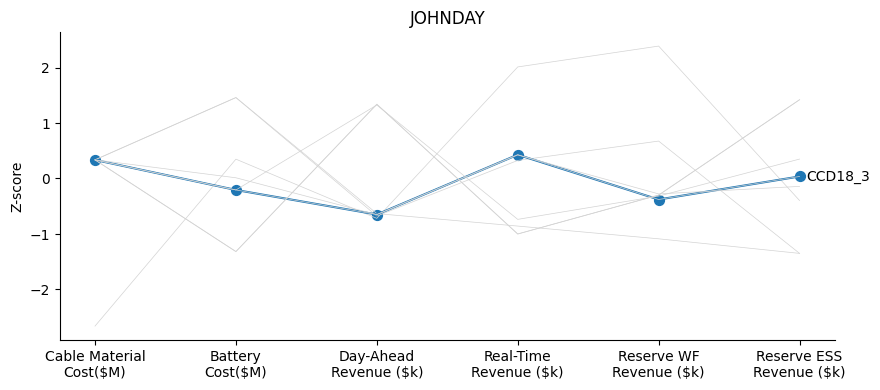

In [6]:
for loc in ["COTTONWOOD", "TESLA", "MOSSLAND", "WCASCADE", "JOHNDAY"]:
    self = tl.DirectTradeoffLattice(
        df_design.loc[(slice(None), loc), :].droplevel(1), ovars, dvars,
        ascending=ascending,
        # max_specializers=1,
        # min_specializers=1,
        n_generalizers=1,
    )
    
    plt.figure(figsize=(10, 4))
    self.plot_ovars_parallel_coords(
        x_label_format=ovar_format,
        use_rank=False,
        include_all_generalizers=True,
        reorder=False,
        highlight_generalizers=True
        # facets = [
        #     i[1]
        #     for i in self.rank.index
        # ]
    )
    plt.title(loc)
    
    plt.subplots_adjust(hspace=1)

## Which scenarios are the best?
- Which scenario is the best - maximize overall revenue?
- Which scenario is the worst - minimal revenue?
- Which scenarios are sensitive to specific objectives?
- Which scenarios generalize well across all the objectives?

In [7]:
ascending = []
ovars_scenario = ovars[2:]
sel_index = "Base_cotwdpge"
df_design_scenario = pd.read_csv(os.path.join(path, 'design_solutions_per_scenario.csv'), index_col=[0, 1]).loc[sel_index]
rated_power = df_design_scenario["Cable Capacity(MW)"].unique()[0]
df_design_scenario

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
sim,,,,,,,,
22,2600.0,36.2,261.818246,32.184081,53.342842,-11.589288,0.004268,0.004710
23,2600.0,36.2,261.818246,32.184081,53.342842,-3.006324,0.000850,0.002057
24,2600.0,36.2,261.818246,32.184081,53.342842,-5.214967,0.001355,0.001465
25,2600.0,36.2,261.818246,32.184081,53.342842,2.644101,0.000654,0.000158
26,2600.0,36.2,261.818246,32.184081,53.342842,17.872314,0.023466,0.004765
...,...,...,...,...,...,...,...,...
117,2600.0,36.2,261.818246,32.184081,1.201874,0.073118,0.000046,0.001611
118,2600.0,36.2,261.818246,32.184081,1.201874,0.206525,0.000383,0.001360
119,2600.0,36.2,261.818246,32.184081,1.201874,-0.205468,0.000567,0.009071


In [8]:
df_scenario = pd.read_csv(os.path.join(path, 'scenarios_wrevenues.csv'), index_col=[0, 1, 2]).loc[sel_index]
df_scenario

ChS      DisS        SCS       WPQ       WSQ  kBS       kWS  \
sim time                                                                     
22  0     0.005304  0.002016  72.400653  0.000000  1.631244  2.0  0.000000   
    1     0.006830  0.001833  72.401701  0.000000  1.631244  2.0  0.000000   
    2     0.009288  0.001677  72.403353  0.000000  1.631244  2.0  0.000000   
    3     0.013716  0.001543  72.406050  0.000000  1.631244  2.0  0.000000   
    4     0.024299  0.001415  72.411189  0.000000  1.656754  2.0  0.000000   
...            ...       ...        ...       ...       ...  ...       ...   
121 91    0.057586  0.181982   0.138868  1.143338  2.831317  2.0  0.006317   
    92    0.094833  0.116952   0.128312  0.000000  2.741472  2.0  0.000000   
    93    0.087642  0.137289   0.110534  0.000000  2.741472  2.0  0.000000   
    94    0.080859  0.173926   0.081147  0.000000  2.741472  2.0  0.000000   
    95    0.073323  0.286643   0.019080  0.000000  2.741472  2.0  0.000000   

                lam_DAQ         lam_RT     pRBDS  ...      pWSQ          v1  \
sim time                                          ...                         
22  0     111068.493725  113957.371061  1.508333  ...  0.000000  475.731414   
    1     111068.493725  111151.766882  1.508333  ...  0.000000  475.729736   
    2     111068.493725  108346.162703  1.508333  ...  0.000000  475.728057   
    3     111068.493725  105540.558524  1.508333  ...  0.000000  475.726378   
    4     100218.649657  102734.954344  1.508333  ...  0.000000  475.723523   
...                 ...            ...       ...  ...       ...         ...   
121 91    163680.830824  134271.586201  1.508333  ...  1.093234  480.217598   
    92    148412.687808  131484.129416  1.508333  ...  0.000000  475.671659   
    93    148412.687808  130878.298467  1.508333  ...  0.000000  475.671371   
    94    148412.687808  130272.467519  1.508333  ...  0.000000  475.671202   
    95    148412.687808  129666.636570  1.508333  ...  0.000000  475.670965   

                  v2        WS        pWDS       pWS  Day-Ahead Revenue ($k)  \
sim time                                                                       
22  0     475.731415  1.631244  750.441807  0.000000                1.825421   
    1     475.729736  1.631244  750.441807  0.000000                     NaN   
    2     475.728058  1.631244  750.441807  0.000000                     NaN   
    3     475.726379  1.631244  750.441807  0.000000                     NaN   
    4     475.723523  1.656754  716.536060  0.000000                1.572685   
...              ...       ...         ...       ...                     ...   
121 91    480.212294  2.831317   43.235001  1.093234                     NaN   
    92    475.671675  2.741472    4.894323  0.000000                0.003889   
    93    475.671388  2.741472    4.894323  0.000000                     NaN   
    94    475.671220  2.741472    4.894323  0.000000                     NaN   
    95    475.670985  2.741472    4.894323  0.000000                     NaN   

          Reserve ESS Revenue ($k)  Reserve WF Revenue ($k)  \
sim time                                                      
22  0                 2.756143e-05             0.000000e+00   
    1                 2.818572e-05             0.000000e+00   
    2                 2.881002e-05             0.000000e+00   
    3                 2.943431e-05             0.000000e+00   
    4                 3.005861e-05             0.000000e+00   
...                            ...                      ...   
121 91                5.802918e-07             1.807893e-09   
    92                8.794077e-08             0.000000e+00   
    93                4.331705e-08             0.000000e+00   
    94               -1.306666e-09             0.000000e+00   
    95               -4.593039e-08             0.000000e+00   

          Real-Time Revenue ($k)  
sim time                          
22  0                  -0.169856  
    1 

In [9]:
def plot_scenario(scenario_frame, rated_power):
    fig, ax = plt.subplots(2, 3, figsize=(12, 5))
    (scenario_frame[["lam_RT", "lam_DAQ"]] / rated_power).plot(ax=ax[0, 0])
    (scenario_frame[["pWRS", "pWDSQ", "pWSQ"]] / 1000).plot(ax=ax[0, 1])
    (scenario_frame["DisS"]-scenario_frame["ChS"]).plot(ax=ax[0, 2])
    
    (scenario_frame[["Day-Ahead Revenue ($k)"]].ffill()).plot(ax=ax[1, 0])
    (scenario_frame[["Real-Time Revenue ($k)"]]).plot(ax=ax[1, 1])
    (scenario_frame[['Reserve ESS Revenue ($k)', 'Reserve WF Revenue ($k)']]).plot(ax=ax[1, 2])
    # It should be DisS - ChS
    
    fig.tight_layout()

### Which solution is the best - maximizing total revenue (sum of objective functions)

Cable Capacity(MW)          2600.000000
Battery Rated Power(MW)       36.200000
Cable Material Cost($M)      261.818246
Battery Cost($M)              32.184081
Day-Ahead Revenue ($k)       136.196299
Real-Time Revenue ($k)        10.871624
Reserve WF Revenue ($k)        0.078170
Reserve ESS Revenue ($k)       0.015887
Name: 87, dtype: float64

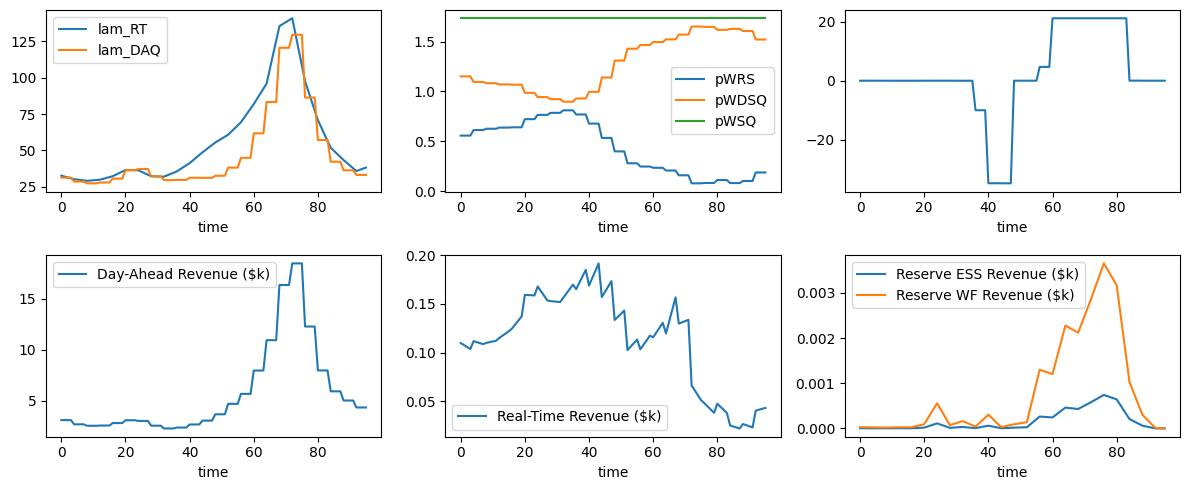

In [10]:
solution_id = df_design_scenario[ovars_scenario].sum(axis=1).sort_values(ascending=False).index.values[0]
plot_scenario(df_scenario.loc[solution_id], rated_power)
df_design_scenario.loc[solution_id]

### Which scenario is the worst - minimal revenue?

Cable Capacity(MW)          2600.000000
Battery Rated Power(MW)       36.200000
Cable Material Cost($M)      261.818246
Battery Cost($M)              32.184081
Day-Ahead Revenue ($k)         1.201874
Real-Time Revenue ($k)        -0.205468
Reserve WF Revenue ($k)        0.000567
Reserve ESS Revenue ($k)       0.009071
Name: 119, dtype: float64

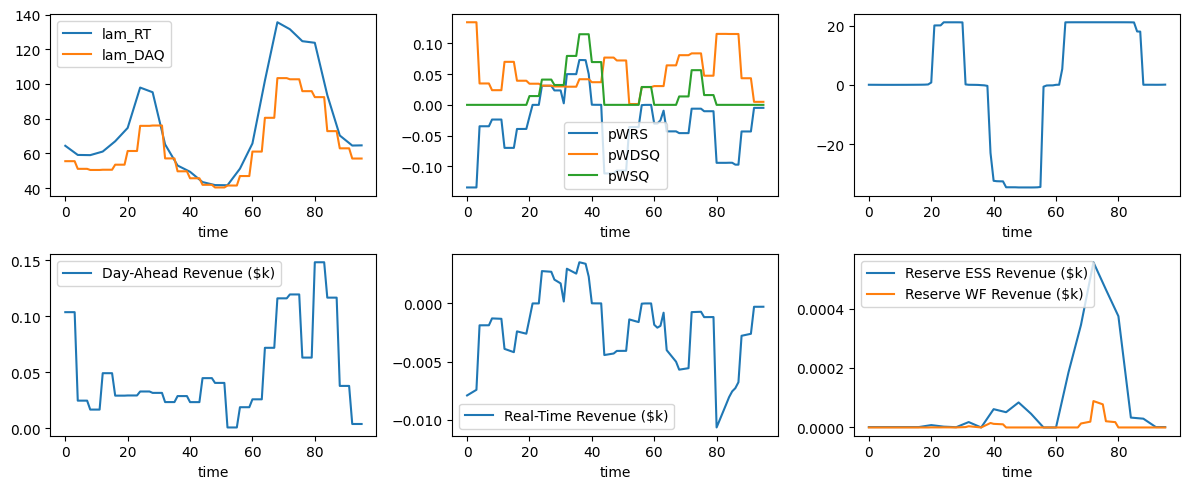

In [11]:
solution_id = df_design_scenario[ovars_scenario].sum(axis=1).sort_values(ascending=True).index.values[0]
plot_scenario(df_scenario.loc[solution_id], rated_power)
df_design_scenario.loc[solution_id]

### Which scenarios are sensitive to specific objectives?

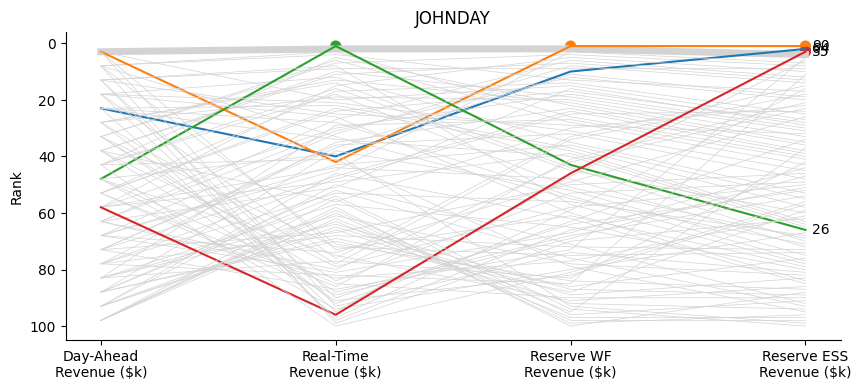

In [12]:
self = tl.DirectTradeoffLattice(
    df_design_scenario, ovars_scenario, dvars,
    ascending=ascending,
    # max_specializers=3,
    min_specializers=1,
    # n_generalizers=2,
)

plt.figure(figsize=(10, 4))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    use_rank=True,
    include_all_generalizers=True,
    reorder=False,
    highlight_generalizers=False,
    # facets = [
    #     i[1]
    #     for i in self.rank.index
    # ]
)
plt.title(loc)

plt.subplots_adjust(hspace=1)

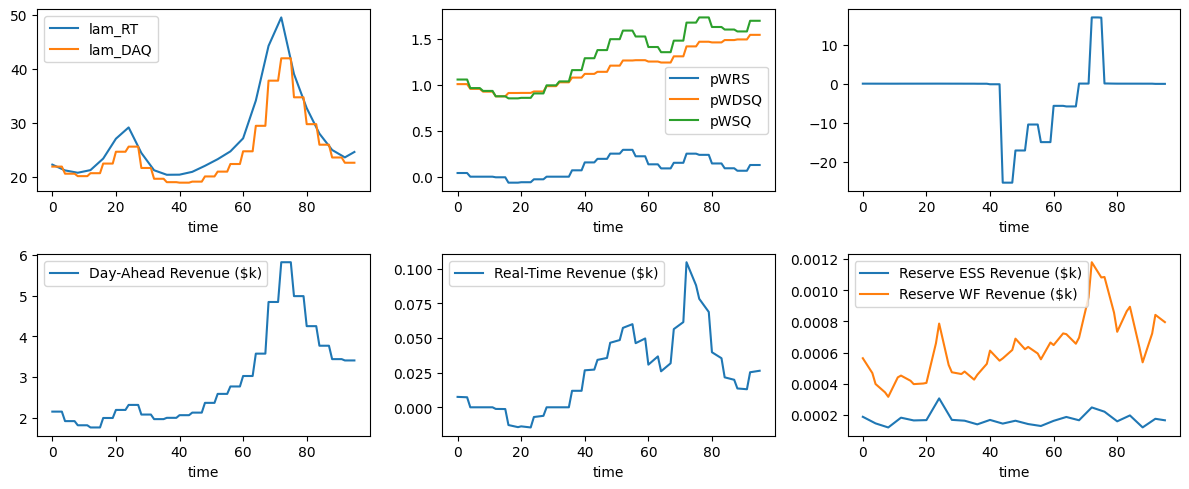

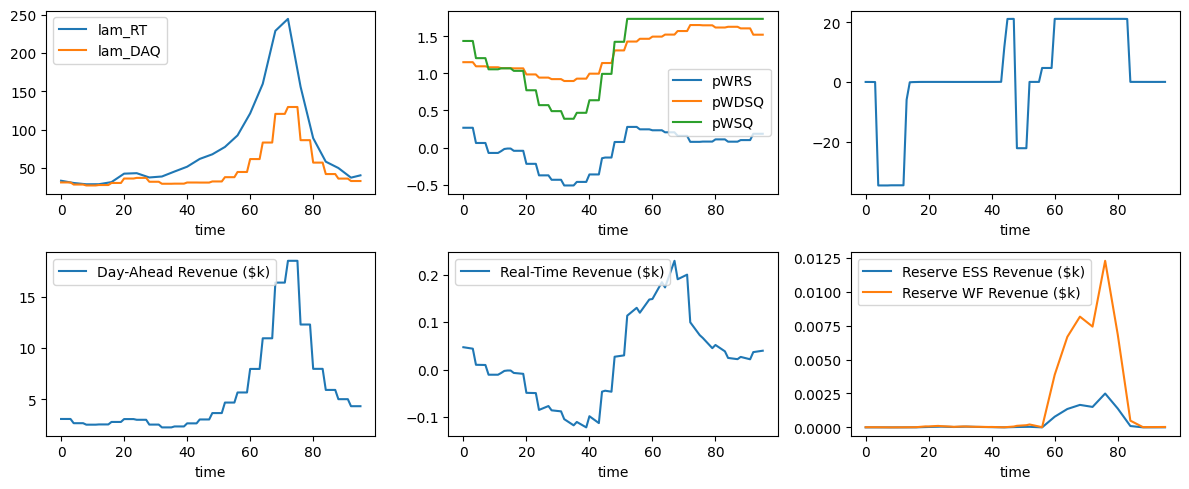

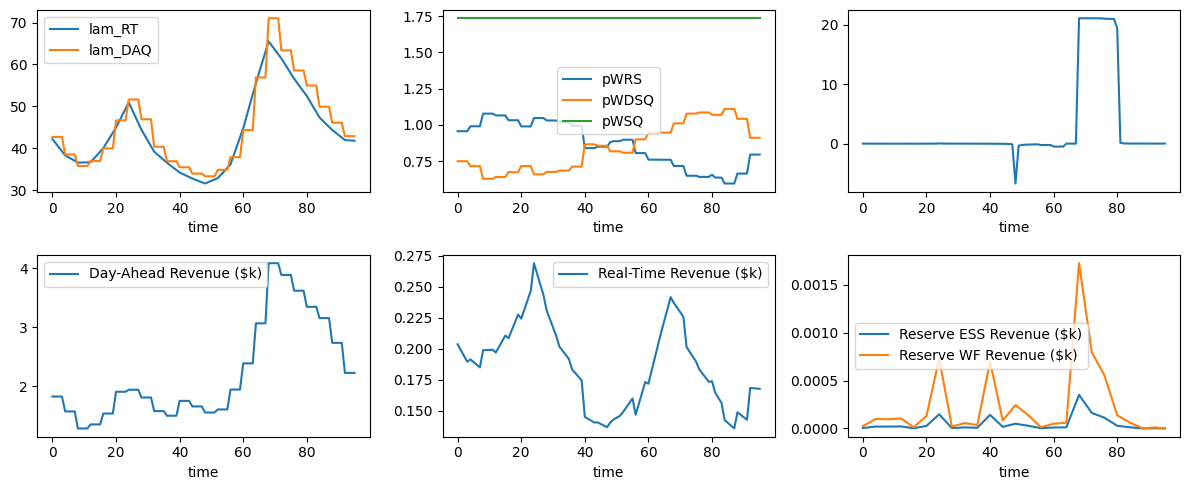

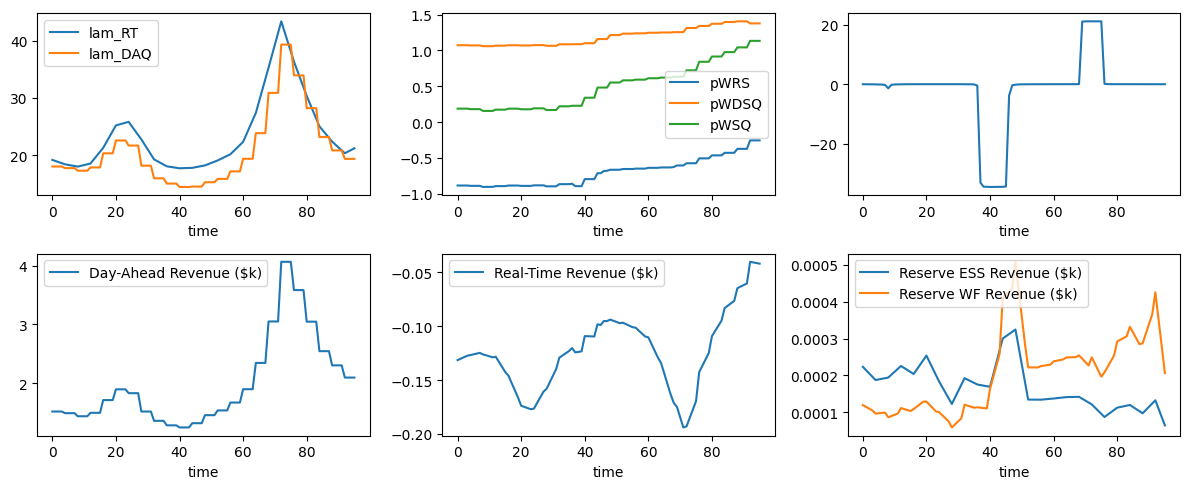

In [13]:
for s in self.specializers.index.values:
    plot_scenario(df_scenario.loc[s], rated_power)

### Which scenarios are resilient?

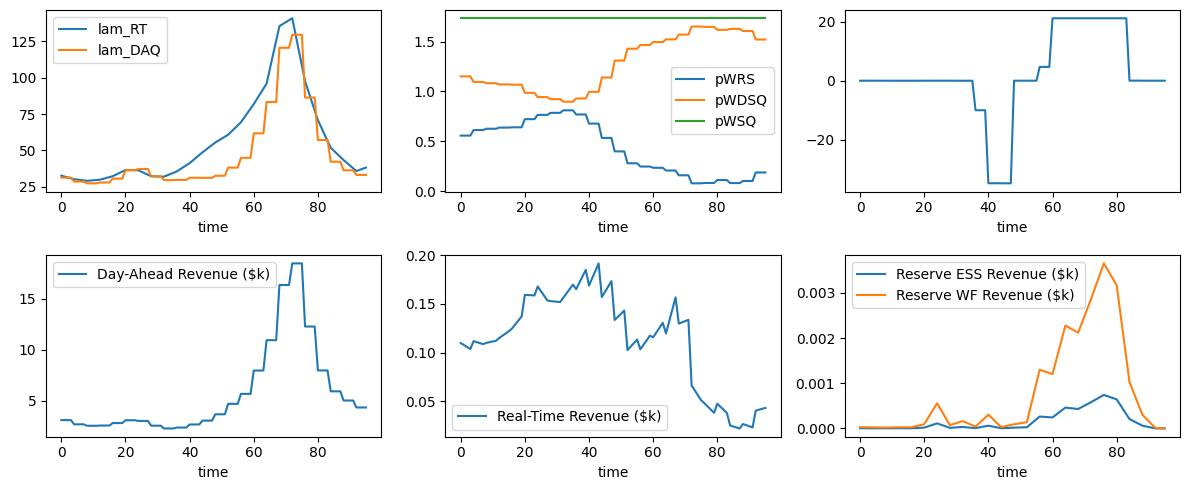

In [14]:
for s in self.generalizers.values:
    plot_scenario(df_scenario.loc[s], rated_power)

### How many more such scenarios exist?

In [15]:
from tslearn.metrics import dtw_path

def closest_series(ts_matrix, reference_col, n=1):
    # Extract reference time series
    reference_ts = ts_matrix[reference_col].values
    
    # Dictionary to store distances
    distances = {}
    
    # Loop through all candidate time series (excluding the reference)
    for col in ts_matrix.columns:
        if col == reference_col:
            continue
        candidate_ts = ts_matrix[col].values.reshape(-1, 1)  # reshape for tslearn compatibility
        _, dist = dtw_path(reference_ts.reshape(-1, 1), candidate_ts)
        distances[col] = dist
    
    # Sort and get top 10 closest
    top_n = sorted(distances.items(), key=lambda x: x[1])[:n]

    return top_n

In [16]:
df_scenario.columns

Index(['ChS', 'DisS', 'SCS', 'WPQ', 'WSQ', 'kBS', 'kWS', 'lam_DAQ', 'lam_RT',
       'pRBDS', 'pRBUS', 'pRWDS', 'pRWUS', 'pWDSQ', 'pWRS', 'pWSQ', 'v1', 'v2',
       'WS', 'pWDS', 'pWS', 'Day-Ahead Revenue ($k)',
       'Reserve ESS Revenue ($k)', 'Reserve WF Revenue ($k)',
       'Real-Time Revenue ($k)'],
      dtype='object')

In [82]:
n = 10
reference_col = 90
# ts_matrix = df_scenario["lam_RT"]-df_scenario["lam_DAQ"]
# ts_matrix = df_scenario["WS"]
ts_matrix = df_scenario["pWRS"]

top_n = closest_series(ts_matrix.unstack(level=0), reference_col, n)

# Print results
print(f"Top {n} time series closest to '{reference_col}':")
for i, (col, dist) in enumerate(top_n, 1):
    print(f"{i}. {col} — DTW distance: {dist:.4f}")

Top 10 time series closest to '90':
1. 46 — DTW distance: 1434.0779
2. 51 — DTW distance: 1537.2145
3. 115 — DTW distance: 1730.0522
4. 94 — DTW distance: 1772.8256
5. 64 — DTW distance: 1815.5860
6. 118 — DTW distance: 1842.4801
7. 40 — DTW distance: 1872.4288
8. 117 — DTW distance: 1877.7240
9. 74 — DTW distance: 1881.5683
10. 120 — DTW distance: 1887.6816


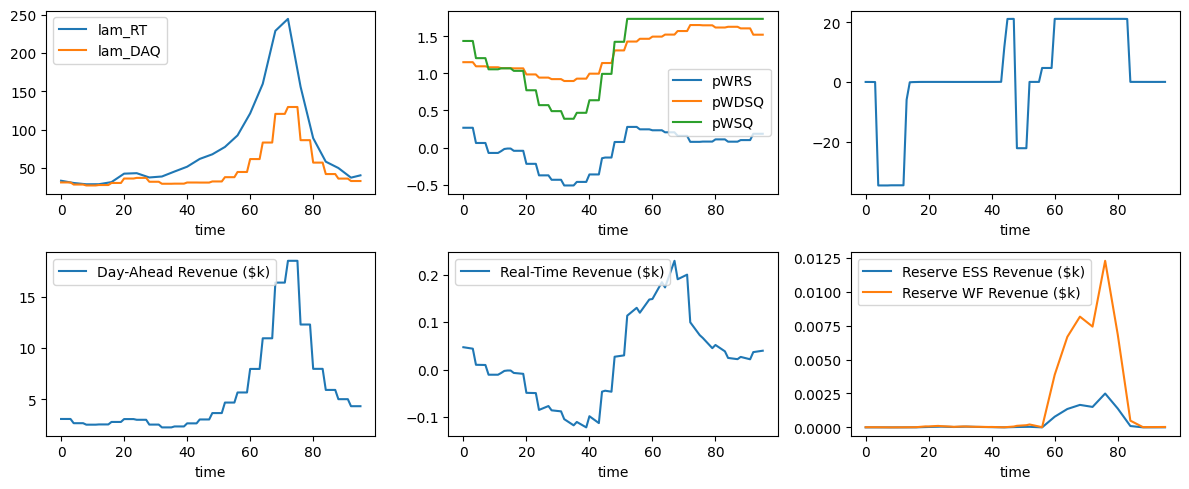

In [83]:
plot_scenario(df_scenario.loc[reference_col], rated_power)

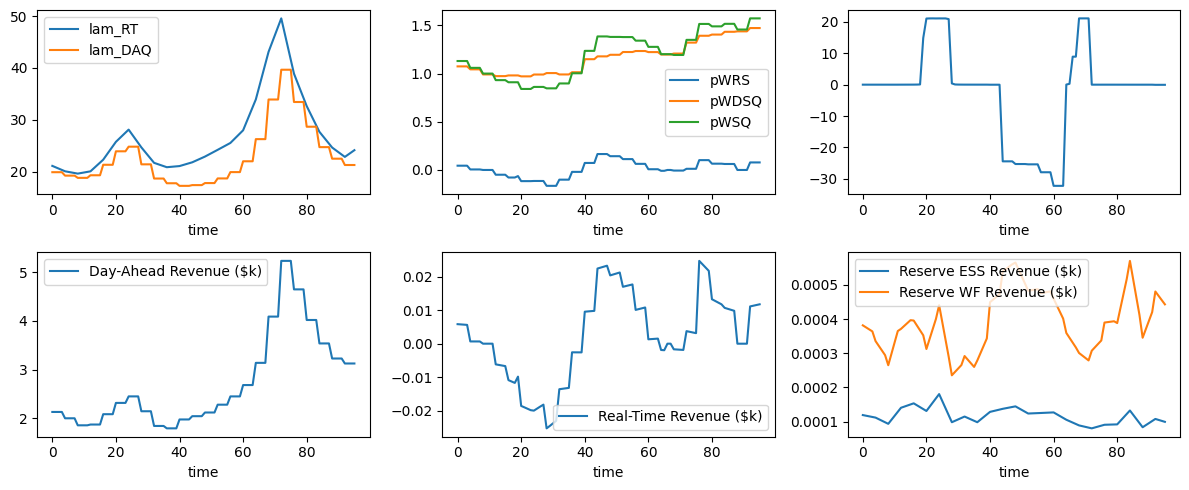

In [84]:
plot_scenario(df_scenario.loc[top_n[0][0]], rated_power)

In [85]:
from tslearn.clustering import TimeSeriesKMeans

seed = 40
n_clusters = 5

X_train = ts_matrix.unstack(level=1)
X_train

time,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
sim,,,,,,,,,,,,,,,,,,,,,
22,-750.445317,-750.447030,-750.449650,-750.454218,-716.559184,-716.565798,-716.576124,-716.594034,-629.676510,-629.670397,...,-351.310362,-351.313717,-383.553630,-383.554503,-383.555193,-383.555734,-343.085427,-343.083459,-343.079970,-343.070233
23,-210.310212,-210.315447,-210.319228,-210.322079,-421.988917,-421.993862,-421.998282,-422.002314,-483.741581,-483.741931,...,-827.494142,-827.707908,-827.069256,-827.246946,-827.306052,-827.335935,-758.995507,-758.976209,-758.942104,-758.834596
24,-606.316703,-606.318507,-606.320129,-606.321608,-643.465750,-643.470548,-643.477382,-643.488078,-582.901727,-582.890265,...,-509.855574,-509.860109,-625.926630,-625.927279,-625.927668,-625.927752,-628.422772,-628.418841,-628.412232,-628.396886
25,178.694519,178.819178,179.174346,196.043920,267.993106,248.975849,247.684631,247.511462,208.976012,208.976421,...,617.984558,617.981147,686.373795,686.364874,686.352222,685.993595,796.086533,796.094043,796.099767,796.104495
26,957.139759,957.138809,957.137894,957.136950,991.041629,991.041102,991.040523,991.039874,1077.999494,1077.999531,...,596.927628,596.925954,665.323063,665.322561,665.322281,665.322255,796.061578,796.063421,796.066523,796.073527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,365.184443,365.180704,365.177226,365.173938,102.712029,102.713071,102.714112,102.715154,79.761012,79.760115,...,43.791417,43.781112,40.491658,40.482903,40.468803,40.443229,8.439138,8.494526,8.507078,8.512854
118,-134.168675,-134.174296,-134.180776,-134.188918,-34.790963,-34.795481,-34.800641,-34.806600,-23.903051,-23.904400,...,49.797370,49.725385,23.942100,23.930328,23.923876,23.921663,0.286525,0.293745,0.300463,0.305884
119,-134.155425,-134.160959,-134.166146,-134.171388,-34.762716,-34.762859,-34.763003,-34.763147,-23.851783,-23.849229,...,-97.098896,-97.148117,-43.219539,-43.219537,-43.219125,-43.218194,-4.890400,-4.883460,-4.871847,-4.838383


/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


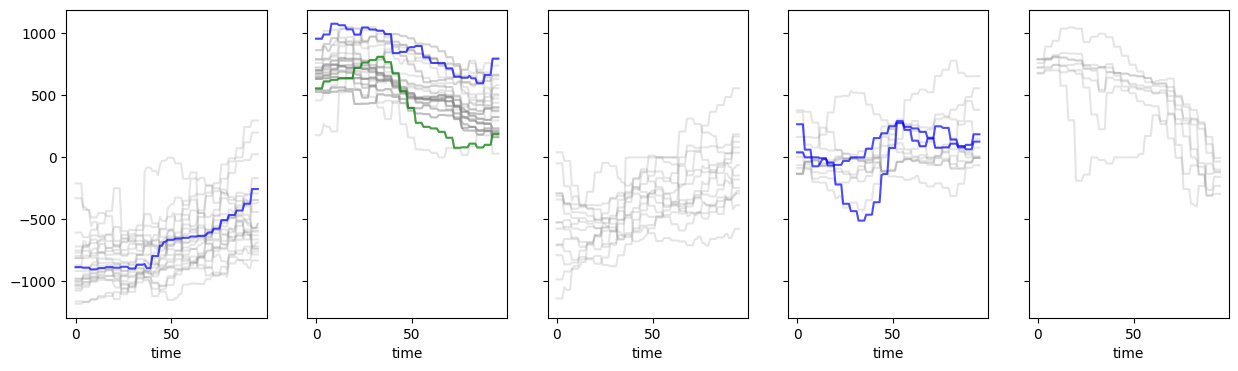

In [86]:
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw",
                         max_iter=10, random_state=seed)
y = model.fit_predict(X_train)

fig, ax = plt.subplots(1, n_clusters, figsize=(3*n_clusters, 4), sharex=True, sharey=True)
for i in range(n_clusters):
    cluster_generalizers = X_train[y==i].index.intersection(self.generalizers)
    cluster_specializers = X_train[y==i].index.intersection(self.specializers.index)
    cluster_else = X_train[y==i].index.difference(self.generalizers.union(self.specializers.index))
    
    if not cluster_else.empty: X_train.loc[cluster_else].T.plot(legend=False, color='grey', ax=ax[i], alpha=0.2)
    if not cluster_generalizers.empty: X_train.loc[cluster_generalizers].T.plot(legend=False, color='green', ax=ax[i], alpha=0.7)
    if not cluster_specializers.empty: X_train.loc[cluster_specializers].T.plot(legend=False, color='blue', ax=ax[i], alpha=0.7)

In [63]:
X_train[y==1]

time,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
sim,,,,,,,,,,,,,,,,,,,,,
61,240.320665,-1635.233446,-3510.787557,-5386.341668,-1382.746726,-2592.347676,-3801.948626,-5011.549575,-1229.122178,-752.502456,...,22425.518201,19463.662509,25476.517627,19279.941549,13083.365471,6886.789394,9191.857904,12462.668041,15733.478178,19004.288315
90,5764.472430,3865.899627,1967.326823,68.754020,5330.723971,4232.446041,3134.168111,2035.890182,4031.389689,4077.575774,...,31206.939701,25831.360889,35857.418500,27694.893172,19532.367845,11369.842517,11446.347596,14061.819308,16677.291020,19292.762732


In [61]:
# from tslearn.clustering import KernelKMeans
# model = KernelKMeans(n_clusters=n_clusters,
#                       kernel="gak",
#                       kernel_params={"sigma": "auto"},
#                       n_init=20,
#                       verbose=True,
#                       random_state=seed)
# y = model.fit_predict(X_train)

# fig, ax = plt.subplots(1, n_clusters, figsize=(3*n_clusters, 4), sharex=True, sharey=True)
# for i in range(n_clusters):
#     cluster_generalizers = X_train[y==i].index.intersection(self.generalizers)
#     cluster_specializers = X_train[y==i].index.intersection(self.specializers.index)
#     cluster_else = X_train[y==i].index.difference(self.generalizers.union(self.specializers.index))
    
#     if not cluster_else.empty: X_train.loc[cluster_else].T.plot(legend=False, color='grey', ax=ax[i], alpha=0.2)
#     if not cluster_generalizers.empty: X_train.loc[cluster_generalizers].T.plot(legend=False, color='green', ax=ax[i], alpha=0.7)
#     if not cluster_specializers.empty: X_train.loc[cluster_specializers].T.plot(legend=False, color='blue', ax=ax[i], alpha=0.7)

In [60]:
### In which cluster does specializer and generalizers lie?

In [22]:
### Can we explain these clusters?